In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Untitled Diagram.drawio',
 'heart_failure_clinical_records_dataset.csv',
 'diabetes (1).csv',
 'job_salary_prediction_dataset.csv',
 'Student_performance_data _.csv',
 'Mall Customers.xlsx']

In [ ]:
# ================================
# LOAD MALL CUSTOMERS DATASET
# ================================

import pandas as pd

# Load Excel file from Google Drive
df = pd.read_excel('/content/drive/MyDrive/Mall Customers.xlsx')

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [ ]:
# ================================
# TASK 1: DATASET LOADING & EXPLORATION
# ================================

# First 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Number of records and features
print("\nNumber of Records:", df.shape[0])
print("Number of Features:", df.shape[1])

# Numerical columns
print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64', 'float64']).columns)

# Categorical columns
print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns)

First 5 Rows:
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  

Dataset Shape:
(200, 7)

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Education                 object
Marital Status            object
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Summary Statistics:
       CustomerID         Age  Annual Income (k$)  

In [ ]:
# ================================
# TASK 2: DATA PREPROCESSING
# ================================

from sklearn.preprocessing import StandardScaler

# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Select numerical columns only
numerical_data = df.select_dtypes(include=['int64', 'float64'])

# Standardize data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numerical_data)

print("\nScaled Data Preview:")
print(scaled_data[:5])

Missing Values:

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Scaled Data Preview:
[[-1.7234121  -1.42456879 -1.73899919 -0.43480148]
 [-1.70609137 -1.28103541 -1.73899919  1.19570407]
 [-1.68877065 -1.3528021  -1.70082976 -1.71591298]
 [-1.67144992 -1.13750203 -1.70082976  1.04041783]
 [-1.6541292  -0.56336851 -1.66266033 -0.39597992]]


In [ ]:
# ================================
# TASK 3: CLUSTER FORMATION
# ================================

from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# Train model
kmeans.fit(scaled_data)

# Cluster labels
labels = kmeans.labels_

# Add cluster column
df['Cluster'] = labels

# Display dataset
print(df.head())

   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  Cluster  
0                      39        2  
1                      81        2  
2                       6        2  
3                      77        2  
4                      40        2  


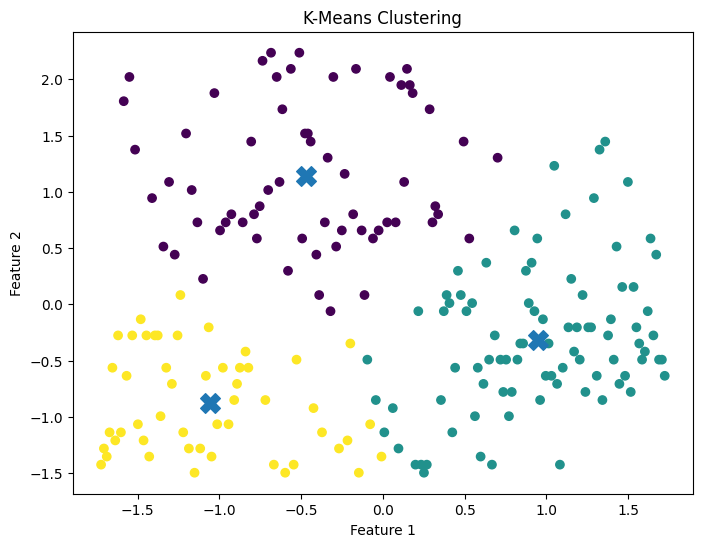

In [ ]:
# ================================
# TASK 4: CLUSTER VISUALIZATION
# ================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=labels
)

# Cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=200
)

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

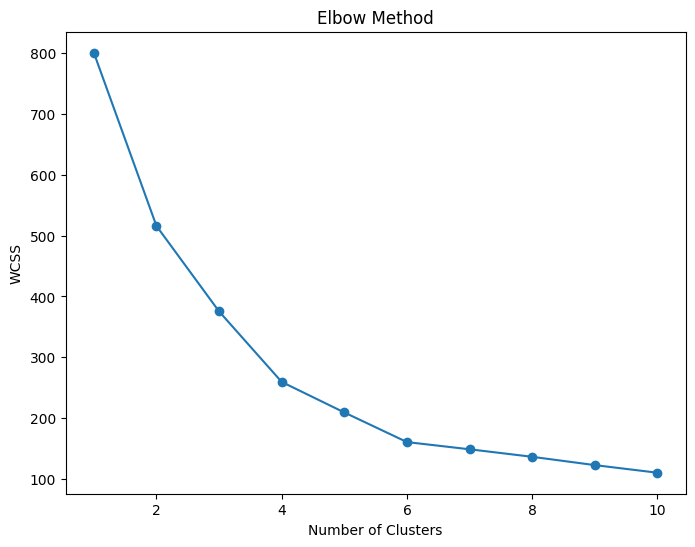

In [ ]:
# ================================
# TASK 5: ELBOW METHOD
# ================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot graph
plt.figure(figsize=(8,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [ ]:
# ================================
# TASK 6: CLUSTER EVALUATION
# ================================

from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.3371428082096961


In [ ]:
# ================================
# TASK 7: PCA DIMENSIONALITY REDUCTION
# ================================

from sklearn.decomposition import PCA

# Reduce dimensions to 2
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print(pca_data[:5])

[[-2.40392421  0.81642336]
 [-2.34841613  1.86676324]
 [-2.39355782 -0.14200822]
 [-2.30712586  1.65321381]
 [-2.33285286  0.23093331]]


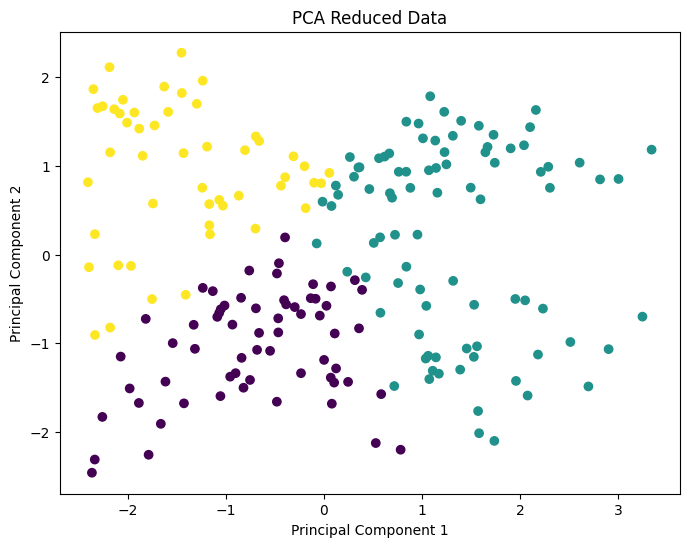

In [ ]:
# ================================
# TASK 8: PCA VISUALIZATION
# ================================

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=labels
)

plt.title('PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()